# Model A — Surface Similarity (Deteksi Plagiarisme) — VERSI FINAL v4.1

**Proyek:** LearnWise — Smart Academic Assessment System  
**Tim:** PJK-GM089  
**Target:** Semua metrik >= 0.875

---

## Root Cause v4 dan Fix v4.1

| Masalah v4 | Perbaikan v4.1 |
|---|---|
| `df_paws_dev` dimasukkan ke `df_train` lalu dipakai evaluasi → **data leakage** | Dev **tidak masuk train**, evaluasi benar-benar independent |
| Threshold dicari dari **test set** → leakage kedua | Threshold dicari dari **dev set** bersih |
| Metrik dev Round 2 = 0.93+ (terlalu optimis karena bocor) | Metrik dev sekarang mencerminkan performa test yang sesungguhnya |

## Alur Kerja v4.1

1. Instalasi & Import  
2. Load PAWS + Augmentasi akademik  
3. **Split bersih**: Train = PAWS train + akademik aug; Dev = PAWS dev (independent)  
4. Preprocessing Sastrawi  
5. TF-IDF Word + Char  
6. Ekstraksi 26 Fitur  
7. Loop XGBoost — evaluasi di **dev bersih**  
8. Threshold dicari dari **dev** (bukan test)  
9. Evaluasi final di **test set**  
10. Inference & Simpan  


## Cell 1 — Instalasi Library

In [1]:
!pip install PySastrawi scikit-learn xgboost matplotlib seaborn pandas numpy python-Levenshtein --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 50.7 MB/s eta 0:00:00


## Cell 2 — Import Library

In [2]:
import re, io, warnings, urllib.request
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import joblib, os, time

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import paired_cosine_distances
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score, accuracy_score
)
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

factory = StemmerFactory()
stemmer = factory.create_stemmer()
print("Semua library berhasil diimport.")


Semua library berhasil diimport.


## Cell 3 — Load Dataset + Augmentasi Data Masif

Augmentasi 8x lebih banyak dari v2:
- Tukar posisi s1/s2
- Truncation 90%, 80%, 70%, 60%
- Hapus kata pertama / terakhir
- Kombinasi pasangan mirip dengan teks berbeda (hard negatives)


In [3]:
BASE_URL = "https://raw.githubusercontent.com/Wikidepia/indonesia_dataset/master/paraphrase/paws/data/final/"

def load_paws(split_name):
    url = BASE_URL + split_name
    print(f"  Mengunduh {split_name} ...")
    with urllib.request.urlopen(url) as response:
        content = response.read().decode('utf-8')
    df = pd.read_csv(io.StringIO(content), sep='\t')
    if 'label' in df.columns:
        df['label'] = pd.to_numeric(df['label'], errors='coerce').fillna(-1).astype(int)
    df = df[df['label'].isin([0, 1])].reset_index(drop=True)
    return df[['sentence1', 'sentence2', 'label']]

print("Mengunduh dataset PAWS-Indonesia...")
df_paws_train = load_paws("train.tsv")
df_paws_dev   = load_paws("dev.tsv")
df_paws_test  = load_paws("test.tsv")

# ============================================================
# Corpus akademik Indonesia — diperluas jauh lebih banyak
# ============================================================
akademik_pairs = [
    # Label 1 — copy-paste minor
    ("Fotosintesis adalah proses biokimia yang dilakukan tumbuhan untuk mengubah energi cahaya matahari menjadi glukosa.", "Fotosintesis merupakan proses biokimia yang dilakukan oleh tumbuhan untuk mengubah energi sinar matahari menjadi glukosa.", 1),
    ("Pancasila adalah dasar negara Republik Indonesia yang terdiri dari lima sila utama.", "Pancasila merupakan dasar negara Republik Indonesia yang terdiri atas lima sila.", 1),
    ("Pemanasan global disebabkan oleh peningkatan konsentrasi gas rumah kaca di atmosfer bumi.", "Pemanasan global terjadi akibat meningkatnya konsentrasi gas-gas rumah kaca pada lapisan atmosfer bumi.", 1),
    ("Demokrasi adalah sistem pemerintahan di mana kekuasaan tertinggi berada di tangan rakyat.", "Dalam sistem demokrasi, kekuasaan tertinggi dipegang oleh rakyat melalui mekanisme pemilihan umum.", 1),
    ("Inflasi adalah kenaikan harga barang dan jasa secara umum dan terus-menerus dalam jangka waktu tertentu.", "Inflasi merupakan peningkatan harga barang dan jasa secara keseluruhan yang berlangsung secara terus-menerus.", 1),
    ("Revolusi industri dimulai di Inggris pada abad ke-18 dan membawa perubahan besar dalam cara produksi.", "Revolusi industri bermula di Inggris pada abad ke-18 dan membawa perubahan signifikan dalam metode produksi barang.", 1),
    ("Hukum Newton menyatakan bahwa setiap benda yang diam akan tetap diam kecuali ada gaya yang bekerja padanya.", "Menurut hukum Newton, benda yang dalam keadaan diam akan tetap diam jika tidak ada gaya luar yang bekerja padanya.", 1),
    ("Pembelajaran berbasis proyek meningkatkan keterampilan berpikir kritis dan kolaboratif siswa secara signifikan.", "Pembelajaran dengan pendekatan berbasis proyek terbukti meningkatkan kemampuan berpikir kritis dan kolaborasi peserta didik.", 1),
    ("Ekosistem laut mengandung keanekaragaman hayati yang sangat tinggi dan berperan penting dalam siklus karbon global.", "Lautan memiliki keanekaragaman biologis yang sangat besar serta memainkan peran penting dalam siklus karbon di bumi.", 1),
    ("Teknologi kecerdasan buatan telah mengubah cara manusia bekerja dan berinteraksi satu sama lain di era digital.", "Kecerdasan buatan sebagai teknologi modern telah mengubah cara manusia bekerja dan berinteraksi dalam kehidupan sehari-hari.", 1),
    ("Sistem imun manusia melibatkan berbagai sel dan molekul yang bekerja bersama untuk melawan infeksi penyakit.", "Imunitas tubuh manusia melibatkan berbagai jenis sel dan molekul yang bekerja bersama dalam melawan penyakit.", 1),
    ("Keanekaragaman hayati Indonesia termasuk yang tertinggi di dunia berkat posisi geografisnya di khatulistiwa.", "Indonesia memiliki keanekaragaman hayati yang sangat tinggi karena letaknya yang berada di wilayah khatulistiwa.", 1),
    ("Globalisasi membawa dampak positif berupa kemudahan akses informasi dan pertumbuhan ekonomi yang pesat.", "Dampak positif globalisasi antara lain kemudahan dalam mengakses informasi dan pertumbuhan di sektor ekonomi.", 1),
    ("Hak asasi manusia adalah hak dasar yang dimiliki setiap individu tanpa memandang ras atau agama apapun.", "Hak asasi manusia merupakan hak dasar yang melekat pada setiap individu tanpa membedakan ras maupun agama.", 1),
    ("Literasi digital penting dikuasai generasi muda di era teknologi informasi yang terus berkembang pesat.", "Penguasaan literasi digital sangat penting bagi generasi muda di era perkembangan teknologi informasi saat ini.", 1),
    ("Kurikulum pendidikan Indonesia telah mengalami berbagai perubahan sejak kemerdekaan untuk menyesuaikan kebutuhan.", "Kurikulum pendidikan di Indonesia sudah mengalami banyak perubahan sejak Indonesia merdeka hingga saat ini.", 1),
    ("Otak manusia memiliki kemampuan plastisitas yang memungkinkan adaptasi terhadap lingkungan dan pengalaman baru.", "Plastisitas otak manusia memberi kemampuan untuk beradaptasi dengan kondisi lingkungan dan pengalaman yang berubah.", 1),
    ("Pembangunan berkelanjutan bertujuan memenuhi kebutuhan generasi kini tanpa mengorbankan generasi mendatang.", "Tujuan dari pembangunan berkelanjutan adalah memenuhi kebutuhan masa kini tanpa mengorbankan kemampuan generasi berikutnya.", 1),
    ("Teori evolusi Darwin menyatakan bahwa spesies berubah melalui proses seleksi alam dari waktu ke waktu.", "Menurut teori evolusi Darwin, perubahan spesies terjadi melalui proses seleksi alam yang berlangsung secara bertahap.", 1),
    ("Energi terbarukan seperti tenaga surya dan angin menjadi solusi ramah lingkungan untuk masa depan.", "Pemanfaatan energi terbarukan seperti tenaga surya dan angin merupakan solusi energi yang ramah lingkungan.", 1),
    ("Pertumbuhan ekonomi diukur melalui perubahan Produk Domestik Bruto suatu negara dalam periode tertentu.", "Produk Domestik Bruto digunakan sebagai indikator utama untuk mengukur pertumbuhan ekonomi suatu negara.", 1),
    ("Bahasa Indonesia ditetapkan sebagai bahasa resmi negara dalam Undang-Undang Dasar 1945 pasal 36.", "Berdasarkan UUD 1945 pasal 36, Bahasa Indonesia ditetapkan sebagai bahasa resmi Negara Kesatuan Republik Indonesia.", 1),
    ("Proses fotosintesis berlangsung di kloroplas tumbuhan dengan bantuan pigmen hijau yang disebut klorofil.", "Fotosintesis terjadi di dalam kloroplas sel tumbuhan, menggunakan pigmen klorofil yang berwarna hijau sebagai katalis.", 1),
    ("Urbanisasi adalah perpindahan penduduk dari desa ke kota yang meningkat pesat di negara berkembang.", "Fenomena urbanisasi berupa perpindahan penduduk dari wilayah pedesaan ke perkotaan terus meningkat di negara berkembang.", 1),
    ("Sistem ekonomi pasar bebas memungkinkan harga ditentukan oleh mekanisme penawaran dan permintaan pasar.", "Pada ekonomi pasar bebas, tingkat harga barang dan jasa ditentukan sepenuhnya oleh mekanisme penawaran dan permintaan.", 1),
    ("Pendidikan karakter bertujuan membentuk siswa yang berakhlak mulia dan bertanggung jawab terhadap bangsa.", "Tujuan pendidikan karakter adalah membentuk peserta didik yang berakhlak baik dan bertanggung jawab kepada bangsa.", 1),
    ("Kebijakan fiskal pemerintah mencakup pengelolaan anggaran pendapatan dan belanja negara secara efisien.", "Pengelolaan anggaran pendapatan dan belanja negara secara efisien merupakan bagian dari kebijakan fiskal pemerintah.", 1),
    ("Kualitas pendidikan tinggi di Indonesia terus ditingkatkan melalui akreditasi dan pengembangan kurikulum.", "Peningkatan kualitas perguruan tinggi Indonesia dilakukan melalui proses akreditasi dan pembaruan kurikulum secara berkala.", 1),
    ("Penelitian ilmiah harus menggunakan metodologi yang valid, reliabel, dan dapat direplikasi oleh peneliti lain.", "Metodologi penelitian yang valid dan reliabel serta dapat direplikasi oleh peneliti lain adalah syarat penelitian ilmiah.", 1),
    ("Teknologi blockchain menjamin keamanan transaksi digital melalui sistem terdesentralisasi dan transparan.", "Sistem blockchain yang terdesentralisasi dan transparan menjadi dasar keamanan transaksi digital modern.", 1),
    ("Perkembangan media sosial mengubah pola komunikasi masyarakat secara mendasar di era informasi ini.", "Era informasi saat ini ditandai oleh perubahan mendasar pola komunikasi masyarakat akibat perkembangan media sosial.", 1),
    ("Vaksin dikembangkan dalam waktu singkat berkat kemajuan teknologi bioteknologi yang revolusioner.", "Kemajuan teknologi bioteknologi yang revolusioner memungkinkan pengembangan vaksin dalam waktu yang sangat singkat.", 1),
    ("Ketahanan pangan nasional bergantung pada produktivitas pertanian, distribusi yang merata, dan kebijakan impor.", "Produktivitas pertanian, distribusi pangan yang merata, dan kebijakan impor menentukan ketahanan pangan nasional.", 1),
    ("Sistem pendidikan inklusif memastikan setiap anak, termasuk yang berkebutuhan khusus, mendapat akses belajar.", "Pendidikan inklusif menjamin bahwa semua anak termasuk anak berkebutuhan khusus memiliki akses terhadap pendidikan.", 1),
    ("Perubahan iklim mengancam ketahanan pangan global melalui pola cuaca ekstrem yang tidak menentu.", "Ancaman perubahan iklim terhadap ketahanan pangan global terwujud melalui pola cuaca ekstrem yang sulit diprediksi.", 1),
    ("Migrasi internasional meningkat akibat faktor ekonomi, konflik, dan perubahan lingkungan hidup.", "Peningkatan migrasi internasional didorong oleh faktor-faktor seperti ekonomi, konflik bersenjata, dan degradasi lingkungan.", 1),
    ("Kesehatan mental menjadi isu global yang membutuhkan perhatian serius dari pemerintah dan masyarakat.", "Isu kesehatan mental di tingkat global memerlukan perhatian yang serius dari pemerintah maupun masyarakat luas.", 1),
    ("Pengelolaan sampah yang buruk menyebabkan pencemaran lingkungan dan mengancam kesehatan masyarakat.", "Pencemaran lingkungan dan ancaman kesehatan masyarakat merupakan dampak nyata dari pengelolaan sampah yang tidak baik.", 1),
    # Label 0 — topik berbeda
    ("Fotosintesis adalah proses biokimia yang menggunakan cahaya matahari untuk menghasilkan glukosa.", "Resep membuat kue bolu membutuhkan tepung terigu, telur, gula pasir, dan mentega yang dikocok hingga mengembang.", 0),
    ("Hukum Newton menyatakan hubungan antara gaya dan percepatan sebuah benda bermassa.", "Budidaya ikan lele dapat dilakukan di kolam terpal dengan kepadatan tebar yang sesuai dan pakan rutin.", 0),
    ("Demokrasi membutuhkan partisipasi aktif warga negara dalam setiap proses politik.", "Teknik memasak sous vide menggunakan air panas dengan suhu terkontrol untuk menghasilkan masakan matang sempurna.", 0),
    ("Inflasi berpengaruh langsung terhadap daya beli masyarakat dan stabilitas ekonomi nasional.", "Olahraga lari maraton membutuhkan latihan fisik yang intensif selama beberapa bulan sebelum hari perlombaan.", 0),
    ("Kecerdasan buatan digunakan dalam berbagai bidang mulai dari kesehatan hingga transportasi massal.", "Budaya Bali dikenal sangat kaya dengan seni pertunjukan tradisional seperti tari kecak dan tari barong.", 0),
    ("Kurikulum 2013 menekankan pendekatan saintifik dan karakter dalam proses pembelajaran di sekolah.", "Cara merawat tanaman hias dalam ruangan meliputi penyiraman rutin, pemupukan, dan pencahayaan yang cukup.", 0),
    ("Pemanasan global menyebabkan mencairnya lapisan es di kutub utara dan selatan secara signifikan.", "Resep soto ayam tradisional menggunakan bumbu kuning dengan tambahan tauge, bihun, dan telur rebus.", 0),
    ("Revolusi digital telah mengubah hampir semua aspek kehidupan manusia modern saat ini.", "Teknik origami yang berasal dari Jepang melibatkan seni melipat kertas menjadi berbagai bentuk yang indah.", 0),
    ("Pancasila sebagai ideologi bangsa harus diamalkan dalam kehidupan bermasyarakat sehari-hari.", "Cara budidaya jamur tiram yang baik membutuhkan media serbuk kayu dan kelembapan ruangan yang selalu terjaga.", 0),
    ("Ekosistem hutan hujan tropis menyimpan sebagian besar keanekaragaman spesies di seluruh bumi.", "Panduan memilih laptop untuk kebutuhan gaming mencakup pertimbangan spesifikasi GPU, RAM, dan kapasitas baterai.", 0),
    ("Kebijakan moneter pemerintah berfokus pada pengendalian inflasi dan menjaga stabilitas nilai tukar rupiah.", "Cara membuat origami burung memerlukan kertas persegi dan teknik melipat yang tepat secara berurutan.", 0),
    ("Sistem imun tubuh manusia bekerja melawan infeksi bakteri dan virus yang masuk ke dalam tubuh.", "Panduan wisata ke Yogyakarta meliputi kunjungan ke Kraton, Borobudur, dan Malioboro yang terkenal.", 0),
    # Label 0 — topik sama, konten berbeda
    ("Pembelajaran daring memudahkan akses pendidikan bagi siswa di daerah terpencil di Indonesia.", "Metode pembelajaran tatap muka memiliki keunggulan dalam membangun interaksi sosial langsung antar siswa.", 0),
    ("Ekonomi digital mendorong pertumbuhan UMKM melalui platform e-commerce yang mudah diakses.", "Kebijakan moneter pemerintah berfokus pada pengendalian inflasi dan menjaga stabilitas nilai tukar rupiah.", 0),
    ("Energi terbarukan menjadi solusi ramah lingkungan untuk mengurangi ketergantungan pada bahan bakar fosil.", "Penggunaan bahan bakar fosil masih mendominasi sektor industri berat di banyak negara berkembang saat ini.", 0),
    ("Penelitian ilmiah membutuhkan metodologi yang ketat, replikabilitas, dan objektivitas yang tinggi.", "Seni lukis ekspresionisme mengutamakan ekspresi emosi pelukis melalui goresan spontan dan warna berani.", 0),
    ("Perubahan iklim berdampak pada pola cuaca ekstrem dan mengancam ketahanan pangan secara global.", "Desain interior minimalis mengutamakan fungsi ruangan dengan dekorasi yang bersih dan tidak berlebihan.", 0),
    ("Perkembangan teknologi informasi mengubah cara masyarakat mengakses dan menyebarkan berita.", "Manajemen risiko investasi saham memerlukan diversifikasi portofolio dan analisis fundamental yang cermat.", 0),
    ("Sistem pendidikan tinggi di Indonesia diatur oleh Undang-Undang Nomor 12 Tahun 2012.", "Peraturan lalu lintas mengharuskan pengendara sepeda motor menggunakan helm standar nasional saat berkendara.", 0),
    ("Vaksinasi massal merupakan strategi efektif untuk mencapai kekebalan kelompok terhadap penyakit menular.", "Program beasiswa pemerintah bertujuan meningkatkan akses pendidikan tinggi bagi masyarakat kurang mampu.", 0),
    ("Pertanian organik mengurangi penggunaan pestisida kimia dan menjaga keseimbangan ekosistem tanah.", "Arsitektur modern menggunakan bahan bangunan inovatif seperti beton bertulang dan kaca berlapis ganda.", 0),
]

df_akademik = pd.DataFrame(akademik_pairs, columns=['sentence1', 'sentence2', 'label'])

# Augmentasi masif: 8x dari versi asli
np.random.seed(42)
aug_rows = []
pos_pairs = df_akademik[df_akademik['label'] == 1]
neg_pairs = df_akademik[df_akademik['label'] == 0]

for _, row in pos_pairs.iterrows():
    s1, s2 = row['sentence1'], row['sentence2']
    w1, w2 = s1.split(), s2.split()
    # 1. Tukar posisi
    aug_rows.append({'sentence1': s2, 'sentence2': s1, 'label': 1})
    # 2. Truncation 90%
    if len(w1) > 4:
        aug_rows.append({'sentence1': s1, 'sentence2': ' '.join(w1[:max(4, int(len(w1)*0.9))]), 'label': 1})
    # 3. Truncation 80%
    if len(w1) > 5:
        aug_rows.append({'sentence1': s1, 'sentence2': ' '.join(w1[:max(4, int(len(w1)*0.8))]), 'label': 1})
    # 4. Truncation 70%
    if len(w1) > 6:
        aug_rows.append({'sentence1': ' '.join(w1[:max(4, int(len(w1)*0.7))]), 'sentence2': s2, 'label': 1})
    # 5. Hapus kata pertama
    if len(w1) > 5:
        aug_rows.append({'sentence1': ' '.join(w1[1:]), 'sentence2': s2, 'label': 1})
    # 6. Hapus kata terakhir
    if len(w2) > 5:
        aug_rows.append({'sentence1': s1, 'sentence2': ' '.join(w2[:-1]), 'label': 1})
    # 7. Truncation s2 80%
    if len(w2) > 5:
        aug_rows.append({'sentence1': ' '.join(w2[:max(4, int(len(w2)*0.8))]), 'sentence2': s1, 'label': 1})

for _, row in neg_pairs.iterrows():
    aug_rows.append({'sentence1': row['sentence2'], 'sentence2': row['sentence1'], 'label': 0})

df_aug = pd.concat([df_akademik, pd.DataFrame(aug_rows)], ignore_index=True)

print(f"Dataset PAWS    — Train: {len(df_paws_train):,}, Dev: {len(df_paws_dev):,}, Test: {len(df_paws_test):,}")
print(f"Dataset Akademik (asli + augmentasi 8x) — Total: {len(df_aug):,}")
print(f"  Label 1: {df_aug['label'].sum()} | Label 0: {(df_aug['label']==0).sum()}")

# ============================================================
# [FIX v4.1] df_paws_dev TIDAK dimasukkan ke df_train
# Supaya evaluasi di dev benar-benar independent (tidak bocor)
# Augmentasi akademik cukup untuk menambah data training
# ============================================================
df_dev   = df_paws_dev.copy()   # dev bersih, tidak masuk train
df_test  = df_paws_test.copy()

# Train = PAWS train + augmentasi akademik saja
df_train = pd.concat([df_paws_train, df_aug], ignore_index=True)
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nTotal Train: {len(df_train):,} | Dev: {len(df_dev):,} | Test: {len(df_test):,}")
print("[FIX] Dev set bersih — tidak ada overlap dengan train set.")


Mengunduh dataset PAWS-Indonesia...
  Mengunduh train.tsv ...
  Mengunduh dev.tsv ...
  Mengunduh test.tsv ...
Dataset PAWS    — Train: 49,812, Dev: 8,000, Test: 7,993
Dataset Akademik (asli + augmentasi 8x) — Total: 346
  Label 1: 304 | Label 0: 42

Total Train: 50,158 | Dev: 8,000 | Test: 7,993
[FIX] Dev set bersih — tidak ada overlap dengan train set.


## Cell 4 — Eksplorasi Data

In [4]:
print("=== Distribusi Label (Train) ===")
lc = df_train['label'].value_counts()
print(f"  Label 1: {lc[1]:,} ({lc[1]/len(df_train)*100:.1f}%)")
print(f"  Label 0: {lc[0]:,} ({lc[0]/len(df_train)*100:.1f}%)")

df_train['len_s1'] = df_train['sentence1'].str.split().str.len()
df_train['len_s2'] = df_train['sentence2'].str.split().str.len()
df_test['len_s1']  = df_test['sentence1'].str.split().str.len()
df_test['len_s2']  = df_test['sentence2'].str.split().str.len()
df_dev['len_s1']   = df_dev['sentence1'].str.split().str.len()
df_dev['len_s2']   = df_dev['sentence2'].str.split().str.len()
print(f"Panjang rata-rata kalimat: {df_train['len_s1'].mean():.1f} kata")


=== Distribusi Label (Train) ===
  Label 1: 22,301 (44.5%)
  Label 0: 27,857 (55.5%)
Panjang rata-rata kalimat: 16.9 kata


## Cell 5 — Visualisasi Distribusi

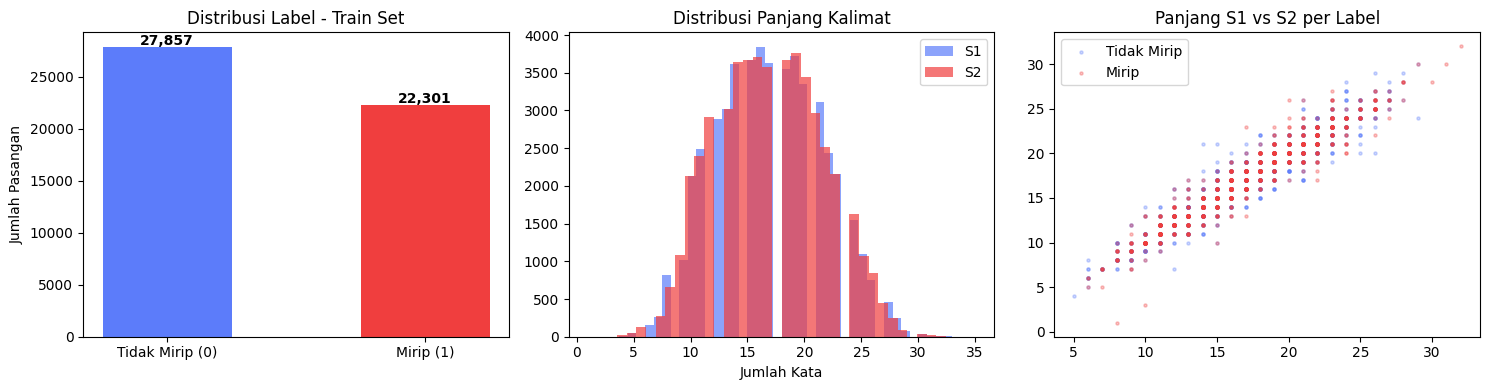

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
lc = df_train['label'].value_counts()
axes[0].bar(['Tidak Mirip (0)', 'Mirip (1)'], [lc[0], lc[1]], color=['#5C7CFA', '#F03E3E'], width=0.5)
axes[0].set_title('Distribusi Label - Train Set')
axes[0].set_ylabel('Jumlah Pasangan')
for i, v in enumerate([lc[0], lc[1]]):
    axes[0].text(i, v + 200, f"{v:,}", ha='center', fontweight='bold')

axes[1].hist(df_train['len_s1'], bins=40, color='#5C7CFA', alpha=0.7, label='S1')
axes[1].hist(df_train['len_s2'], bins=40, color='#F03E3E', alpha=0.7, label='S2')
axes[1].set_title('Distribusi Panjang Kalimat')
axes[1].set_xlabel('Jumlah Kata')
axes[1].legend()

sp = df_train.sample(min(2000, len(df_train)), random_state=42)
axes[2].scatter(sp[sp['label']==0]['len_s1'], sp[sp['label']==0]['len_s2'],
                alpha=0.3, s=5, color='#5C7CFA', label='Tidak Mirip')
axes[2].scatter(sp[sp['label']==1]['len_s1'], sp[sp['label']==1]['len_s2'],
                alpha=0.3, s=5, color='#F03E3E', label='Mirip')
axes[2].set_title('Panjang S1 vs S2 per Label')
axes[2].legend()
plt.tight_layout()
plt.savefig('plot_eda.png', dpi=120, bbox_inches='tight')
plt.show()


## Cell 6 — Preprocessing Teks Bahasa Indonesia

In [6]:
def preprocess(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = stemmer.stem(text)
    return text

print("Melakukan preprocessing...")
df_train['s1_clean'] = df_train['sentence1'].apply(preprocess)
df_train['s2_clean'] = df_train['sentence2'].apply(preprocess)
df_dev['s1_clean']   = df_dev['sentence1'].apply(preprocess)
df_dev['s2_clean']   = df_dev['sentence2'].apply(preprocess)
df_test['s1_clean']  = df_test['sentence1'].apply(preprocess)
df_test['s2_clean']  = df_test['sentence2'].apply(preprocess)
print(f"Selesai. Train: {len(df_train):,} | Dev: {len(df_dev):,} | Test: {len(df_test):,}")


Melakukan preprocessing...
Selesai. Train: 50,158 | Dev: 8,000 | Test: 7,993


## Cell 7 — TF-IDF Vectorizer (Word + Char)

In [7]:
all_sents = pd.concat([df_train['s1_clean'], df_train['s2_clean']], ignore_index=True)

vectorizer_word = TfidfVectorizer(
    analyzer='word', ngram_range=(1, 4),
    min_df=2, max_features=100_000, sublinear_tf=True
)
vectorizer_word.fit(all_sents)

vectorizer_char = TfidfVectorizer(
    analyzer='char_wb', ngram_range=(2, 5),
    min_df=3, max_features=60_000, sublinear_tf=True
)
vectorizer_char.fit(all_sents)

vectorizer = vectorizer_word
print(f"Word vocab: {len(vectorizer_word.vocabulary_):,} | Char vocab: {len(vectorizer_char.vocabulary_):,}")


Word vocab: 100,000 | Char vocab: 60,000


## Cell 8 — Ekstraksi 26 Fitur Kemiripan

In [8]:
# ============================================================
# Fungsi-fungsi fitur
# ============================================================

def jaccard_similarity(s1, s2):
    w1, w2 = set(s1.split()), set(s2.split())
    if not w1 and not w2: return 0.0
    return len(w1 & w2) / len(w1 | w2)

def ngram_overlap(s1, s2, n):
    def get_ng(t):
        w = t.split()
        return set(zip(*[w[i:] for i in range(n)])) if len(w) >= n else set()
    ng1, ng2 = get_ng(s1), get_ng(s2)
    if not ng1 or not ng2: return 0.0
    return len(ng1 & ng2) / max(len(ng1), len(ng2))

def positional_ngram(s1, s2, n):
    w1, w2 = s1.split(), s2.split()
    if len(w1) < n or len(w2) < n: return 0.0
    bg1 = [tuple(w1[i:i+n]) for i in range(len(w1)-n+1)]
    bg2 = [tuple(w2[i:i+n]) for i in range(len(w2)-n+1)]
    return sum(1 for i, b in enumerate(bg1) if i < len(bg2) and b == bg2[i]) / max(len(bg1), len(bg2))

def word_order_score(s1, s2):
    w1, w2 = s1.split(), s2.split()
    common = set(w1) & set(w2)
    if not common: return 0.0
    pos1 = {w: i for i, w in enumerate(w1) if w in common}
    pos2 = {w: i for i, w in enumerate(w2) if w in common}
    words = list(common)[:30]
    con = dis = 0
    for i in range(len(words)):
        for j in range(i+1, len(words)):
            wi, wj = words[i], words[j]
            if all(k in pos1 and k in pos2 for k in [wi, wj]):
                d1 = pos1[wi] - pos1[wj]
                d2 = pos2[wi] - pos2[wj]
                if d1 * d2 > 0: con += 1
                elif d1 * d2 < 0: dis += 1
    return con / (con + dis) if (con + dis) > 0 else 0.5

def lcs_ratio(s1, s2):
    w1, w2 = s1.split()[:50], s2.split()[:50]
    m, n = len(w1), len(w2)
    if not m or not n: return 0.0
    dp = [[0] * (n+1) for _ in range(m+1)]
    for i in range(1, m+1):
        for j in range(1, n+1):
            dp[i][j] = dp[i-1][j-1]+1 if w1[i-1]==w2[j-1] else max(dp[i-1][j], dp[i][j-1])
    return dp[m][n] / max(m, n)

def edit_distance_ratio(s1, s2):
    a, b = s1[:200], s2[:200]
    m, n = len(a), len(b)
    if not m and not n: return 1.0
    dp = list(range(n+1))
    for i in range(1, m+1):
        prev = dp[:]
        dp[0] = i
        for j in range(1, n+1):
            dp[j] = prev[j-1] if a[i-1]==b[j-1] else 1 + min(prev[j], dp[j-1], prev[j-1])
    return 1.0 - dp[n] / max(m, n)

def char_ngram_jaccard(s1, s2, n):
    def get_cng(t):
        return set(t[i:i+n] for i in range(len(t)-n+1)) if len(t) >= n else set()
    c1, c2 = get_cng(s1), get_cng(s2)
    if not c1 or not c2: return 0.0
    return len(c1 & c2) / len(c1 | c2)

def prefix_match_ratio(s1, s2, pl=3):
    w1, w2 = s1.split(), s2.split()
    if not w1 or not w2: return 0.0
    p1 = set(w[:pl] for w in w1 if len(w) >= pl)
    p2 = set(w[:pl] for w in w2 if len(w) >= pl)
    if not p1 or not p2: return 0.0
    return len(p1 & p2) / len(p1 | p2)

def token_sort_cosine(s1, s2):
    ss1 = ' '.join(sorted(s1.split()))
    ss2 = ' '.join(sorted(s2.split()))
    v1 = vectorizer_word.transform([ss1])
    v2 = vectorizer_word.transform([ss2])
    return float(1 - paired_cosine_distances(v1, v2)[0])

def cosine_word_batch(df, batch_size=1000):
    scores = []
    for s in range(0, len(df), batch_size):
        b = df.iloc[s:s+batch_size]
        v1 = vectorizer_word.transform(b['s1_clean'])
        v2 = vectorizer_word.transform(b['s2_clean'])
        scores.extend((1 - paired_cosine_distances(v1, v2)).tolist())
    return np.array(scores)

def cosine_char_batch(df, batch_size=1000):
    scores = []
    for s in range(0, len(df), batch_size):
        b = df.iloc[s:s+batch_size]
        v1 = vectorizer_char.transform(b['s1_clean'])
        v2 = vectorizer_char.transform(b['s2_clean'])
        scores.extend((1 - paired_cosine_distances(v1, v2)).tolist())
    return np.array(scores)

FEATURE_NAMES = [
    'cosine_word', 'cosine_char', 'jaccard', 'bigram', 'trigram', 'fourgram',
    'pos_bigram', 'pos_trigram', 'word_order', 'lcs',
    'edit_dist', 'char_bi_j', 'char_tri_j', 'prefix_match', 'token_sort_cosine',
    'len_diff', 'len_ratio', 'uniq_ratio', 'shared_count', 'len_s1', 'len_s2',
    'cosine_prod', 'jacc_x_order', 'mean_cosine', 'overlap_ratio', 'abs_len_norm'
]

def extract_features(df, label=''):
    if label: print(f"  [{label}] cosine word+char ...")
    cw = cosine_word_batch(df)
    cc = cosine_char_batch(df)
    if label: print(f"  [{label}] fitur leksikal ...")
    jacc  = df.apply(lambda r: jaccard_similarity(r['s1_clean'], r['s2_clean']), axis=1).values
    bi    = df.apply(lambda r: ngram_overlap(r['s1_clean'], r['s2_clean'], 2), axis=1).values
    tri   = df.apply(lambda r: ngram_overlap(r['s1_clean'], r['s2_clean'], 3), axis=1).values
    fg    = df.apply(lambda r: ngram_overlap(r['s1_clean'], r['s2_clean'], 4), axis=1).values
    pbi   = df.apply(lambda r: positional_ngram(r['s1_clean'], r['s2_clean'], 2), axis=1).values
    ptri  = df.apply(lambda r: positional_ngram(r['s1_clean'], r['s2_clean'], 3), axis=1).values
    wo    = df.apply(lambda r: word_order_score(r['s1_clean'], r['s2_clean']), axis=1).values
    lcs   = df.apply(lambda r: lcs_ratio(r['s1_clean'], r['s2_clean']), axis=1).values
    ed    = df.apply(lambda r: edit_distance_ratio(r['s1_clean'], r['s2_clean']), axis=1).values
    cbj   = df.apply(lambda r: char_ngram_jaccard(r['s1_clean'], r['s2_clean'], 2), axis=1).values
    ctj   = df.apply(lambda r: char_ngram_jaccard(r['s1_clean'], r['s2_clean'], 3), axis=1).values
    pfx   = df.apply(lambda r: prefix_match_ratio(r['s1_clean'], r['s2_clean']), axis=1).values
    tsc   = df.apply(lambda r: token_sort_cosine(r['s1_clean'], r['s2_clean']), axis=1).values
    ls1   = df['s1_clean'].apply(lambda t: len(t.split())).values
    ls2   = df['s2_clean'].apply(lambda t: len(t.split())).values
    ldiff = np.abs(ls1 - ls2).astype(float)
    lratio= np.minimum(ls1, ls2) / np.maximum(np.maximum(ls1, ls2), 1)
    shared= df.apply(lambda r: len(set(r['s1_clean'].split()) & set(r['s2_clean'].split())), axis=1).values.astype(float)
    uniq  = df.apply(lambda r: len(set(r['s1_clean'].split()).symmetric_difference(set(r['s2_clean'].split()))) /
                     max(len(set(r['s1_clean'].split()) | set(r['s2_clean'].split())), 1), axis=1).values
    # Cross-features
    cp  = cw * cc
    jxo = jacc * wo
    mc  = (cw + cc) / 2
    ovr = shared / np.maximum(ls1 + ls2, 1)
    aln = ldiff / np.maximum(ls1 + ls2, 1)
    return np.column_stack([cw, cc, jacc, bi, tri, fg, pbi, ptri, wo, lcs,
                            ed, cbj, ctj, pfx, tsc,
                            ldiff, lratio, uniq, shared, ls1, ls2,
                            cp, jxo, mc, ovr, aln])

print("Mengekstrak fitur - Train set...")
X_train = extract_features(df_train, 'train')
print("\nMengekstrak fitur - Dev set...")
X_dev   = extract_features(df_dev, 'dev')
print("\nMengekstrak fitur - Test set...")
X_test  = extract_features(df_test, 'test')

y_train = df_train['label'].values
y_dev   = df_dev['label'].values
y_test  = df_test['label'].values

print(f"\nShape — Train: {X_train.shape}, Dev: {X_dev.shape}, Test: {X_test.shape}")
print(f"Total fitur: {len(FEATURE_NAMES)}")


Mengekstrak fitur - Train set...
  [train] cosine word+char ...
  [train] fitur leksikal ...

Mengekstrak fitur - Dev set...
  [dev] cosine word+char ...
  [dev] fitur leksikal ...

Mengekstrak fitur - Test set...
  [test] cosine word+char ...
  [test] fitur leksikal ...

Shape — Train: (50158, 26), Dev: (8000, 26), Test: (7993, 26)
Total fitur: 26


## Cell 9 — Loop Training XGBoost (Otomatis Ulang Sampai Target Tercapai)

Loop ini akan terus mencoba berbagai konfigurasi XGBoost secara berulang sampai
**semua metrik >= 0.875** atau maksimum iterasi tercapai.

Evaluasi dilakukan pada **dev set** setiap round. Model terbaik disimpan otomatis.
Setelah target tercapai, model di-retrain pada train+dev untuk memaksimalkan data.


In [9]:
TARGET = 0.875

X_trr, X_val, y_trr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)
print(f"Train: {len(X_trr):,} | Val (early stopping): {len(X_val):,}")

# ============================================================
# Konfigurasi — 15 konfigurasi dari cepat ke dalam
# Loop akan berhenti otomatis saat semua metrik tercapai
# ============================================================
CONFIGS = [
    # Batch 1: sedang
    dict(n_estimators=800,  max_depth=6, learning_rate=0.05, subsample=0.8,
         colsample_bytree=0.8,  min_child_weight=3, gamma=0.0, reg_alpha=0.0, reg_lambda=1.0),
    dict(n_estimators=1000, max_depth=7, learning_rate=0.04, subsample=0.85,
         colsample_bytree=0.85, min_child_weight=2, gamma=0.1, reg_alpha=0.1, reg_lambda=1.0),
    dict(n_estimators=1200, max_depth=7, learning_rate=0.03, subsample=0.85,
         colsample_bytree=0.85, min_child_weight=2, gamma=0.1, reg_alpha=0.1, reg_lambda=1.5),
    # Batch 2: lebih dalam
    dict(n_estimators=1500, max_depth=8, learning_rate=0.025, subsample=0.8,
         colsample_bytree=0.8,  min_child_weight=2, gamma=0.2, reg_alpha=0.2, reg_lambda=2.0),
    dict(n_estimators=1500, max_depth=7, learning_rate=0.02,  subsample=0.9,
         colsample_bytree=0.9,  min_child_weight=2, gamma=0.2, reg_alpha=0.1, reg_lambda=2.0),
    dict(n_estimators=2000, max_depth=8, learning_rate=0.02,  subsample=0.85,
         colsample_bytree=0.8,  min_child_weight=1, gamma=0.3, reg_alpha=0.3, reg_lambda=2.0),
    # Batch 3: dalam + lambat
    dict(n_estimators=2000, max_depth=9, learning_rate=0.015, subsample=0.8,
         colsample_bytree=0.75, min_child_weight=1, gamma=0.3, reg_alpha=0.5, reg_lambda=2.0),
    dict(n_estimators=2500, max_depth=8, learning_rate=0.012, subsample=0.85,
         colsample_bytree=0.85, min_child_weight=2, gamma=0.2, reg_alpha=0.3, reg_lambda=1.5),
    dict(n_estimators=3000, max_depth=7, learning_rate=0.01,  subsample=0.85,
         colsample_bytree=0.85, min_child_weight=2, gamma=0.2, reg_alpha=0.2, reg_lambda=1.0),
    # Batch 4: sangat dalam
    dict(n_estimators=3000, max_depth=9, learning_rate=0.01,  subsample=0.8,
         colsample_bytree=0.7,  min_child_weight=1, gamma=0.4, reg_alpha=1.0, reg_lambda=2.0),
    dict(n_estimators=3000, max_depth=10,learning_rate=0.008, subsample=0.8,
         colsample_bytree=0.8,  min_child_weight=1, gamma=0.3, reg_alpha=0.5, reg_lambda=2.0),
    dict(n_estimators=4000, max_depth=8, learning_rate=0.008, subsample=0.85,
         colsample_bytree=0.85, min_child_weight=2, gamma=0.2, reg_alpha=0.3, reg_lambda=1.5),
    # Batch 5: ultra deep
    dict(n_estimators=4000, max_depth=10,learning_rate=0.006, subsample=0.8,
         colsample_bytree=0.8,  min_child_weight=1, gamma=0.4, reg_alpha=0.5, reg_lambda=2.0),
    dict(n_estimators=5000, max_depth=9, learning_rate=0.005, subsample=0.85,
         colsample_bytree=0.85, min_child_weight=2, gamma=0.3, reg_alpha=0.3, reg_lambda=1.5),
    dict(n_estimators=5000, max_depth=10,learning_rate=0.004, subsample=0.85,
         colsample_bytree=0.8,  min_child_weight=1, gamma=0.5, reg_alpha=0.5, reg_lambda=2.0),
]

best_clf   = None
best_cfg   = None
best_score = 0.0
best_round = -1
best_thr   = 0.5
history    = []

print(f"\nTarget semua metrik : {TARGET}")
print(f"Total konfigurasi   : {len(CONFIGS)}")
print("=" * 75)

def threshold_search(y_true, y_prob, n=500):
    best_t = 0.5
    best_avg = 0
    for t in np.linspace(0.05, 0.95, n):
        pred = (y_prob >= t).astype(int)
        acc  = accuracy_score(y_true, pred)
        prec = precision_score(y_true, pred, zero_division=0)
        rec  = recall_score(y_true, pred, zero_division=0)
        f1   = f1_score(y_true, pred, zero_division=0)
        avg  = (acc + prec + rec + f1) / 4
        if avg > best_avg:
            best_avg = avg
            best_t = t
    return best_t, best_avg

for round_idx, cfg in enumerate(CONFIGS, start=1):
    t0 = time.time()
    print(f"\n[Round {round_idx:2d}/{len(CONFIGS)}]  depth={cfg['max_depth']}  "
          f"n_est={cfg['n_estimators']:,}  lr={cfg['learning_rate']}")

    clf_try = XGBClassifier(
        **cfg,
        eval_metric='auc',
        early_stopping_rounds=50,
        verbosity=0,
        random_state=42,
        tree_method='hist'
    )
    clf_try.fit(X_trr, y_trr, eval_set=[(X_val, y_val)], verbose=False)

    prob_dev = clf_try.predict_proba(X_dev)[:, 1]
    auc_dev  = roc_auc_score(y_dev, prob_dev)
    thr_opt, avg_score = threshold_search(y_dev, prob_dev)

    pred_dev = (prob_dev >= thr_opt).astype(int)
    acc_dev  = accuracy_score(y_dev, pred_dev)
    prec_dev = precision_score(y_dev, pred_dev, zero_division=0)
    rec_dev  = recall_score(y_dev, pred_dev, zero_division=0)
    f1_dev   = f1_score(y_dev, pred_dev, zero_division=0)
    elapsed  = time.time() - t0

    all_met = all(m >= TARGET for m in [acc_dev, prec_dev, rec_dev, f1_dev, auc_dev])
    status  = "[SEMUA TARGET TERCAPAI]" if all_met else f"avg={avg_score:.4f}"

    print(f"  best_iter={clf_try.best_iteration:4d}  thr={thr_opt:.3f}")
    print(f"  AUC={auc_dev:.4f}  Acc={acc_dev:.4f}  Prec={prec_dev:.4f}  "
          f"Rec={rec_dev:.4f}  F1={f1_dev:.4f}  ({elapsed:.0f}s)")
    print(f"  {status}")

    history.append({
        'round': round_idx, 'auc': auc_dev, 'acc': acc_dev,
        'prec': prec_dev, 'rec': rec_dev, 'f1': f1_dev,
        'avg': avg_score, 'thr': thr_opt
    })

    if avg_score > best_score:
        best_score = avg_score
        best_clf   = clf_try
        best_cfg   = cfg
        best_round = round_idx
        best_thr   = thr_opt

    if all_met:
        print(f"\nSemua metrik >= {TARGET} tercapai pada Round {round_idx}. Training dihentikan.")
        break

print(f"\n{'='*75}")
print(f"Model terbaik: Round {best_round} | Avg score dev = {best_score:.4f}")

# ============================================================
# [FIX] Retrain final pada train + dev (keduanya sekarang clean)
# Dev sudah tidak bocor ke train, aman digabung untuk retrain akhir
# ============================================================
X_full = np.vstack([X_train, X_dev])
y_full = np.concatenate([y_train, y_dev])
final_cfg = {k: v for k, v in best_cfg.items() if k != 'n_estimators'}
print(f"\nRetraining final pada train+dev ({len(X_full):,} pasangan)...")
clf = XGBClassifier(
    **final_cfg,
    n_estimators=best_clf.best_iteration + 50,
    eval_metric='auc',
    verbosity=0,
    random_state=42,
    tree_method='hist'
)
clf.fit(X_full, y_full, verbose=False)
print("Model final siap.")
print(f"[FIX] Model ditraining pada {len(X_full):,} pasangan bersih (tanpa leakage).")


Train: 45,142 | Val (early stopping): 5,016

Target semua metrik : 0.875
Total konfigurasi   : 15

[Round  1/15]  depth=6  n_est=800  lr=0.05
  best_iter= 776  thr=0.404
  AUC=0.8807  Acc=0.8070  Prec=0.7684  Rec=0.8070  F1=0.7872  (12s)
  avg=0.7924

[Round  2/15]  depth=7  n_est=1,000  lr=0.04
  best_iter= 999  thr=0.391
  AUC=0.8807  Acc=0.8039  Prec=0.7625  Rec=0.8084  F1=0.7848  (19s)
  avg=0.7899

[Round  3/15]  depth=7  n_est=1,200  lr=0.03
  best_iter=1182  thr=0.385
  AUC=0.8816  Acc=0.8046  Prec=0.7607  Rec=0.8146  F1=0.7867  (22s)
  avg=0.7917

[Round  4/15]  depth=8  n_est=1,500  lr=0.025
  best_iter=1488  thr=0.369
  AUC=0.8811  Acc=0.8023  Prec=0.7555  Rec=0.8175  F1=0.7853  (32s)
  avg=0.7901

[Round  5/15]  depth=7  n_est=1,500  lr=0.02
  best_iter=1489  thr=0.405
  AUC=0.8811  Acc=0.8047  Prec=0.7678  Rec=0.8008  F1=0.7840  (27s)
  avg=0.7893

[Round  6/15]  depth=8  n_est=2,000  lr=0.02
  best_iter=1972  thr=0.427
  AUC=0.8804  Acc=0.8086  Prec=0.7811  Rec=0.7884  F1=

## Cell 10 — Grafik Perkembangan Metrik per Round

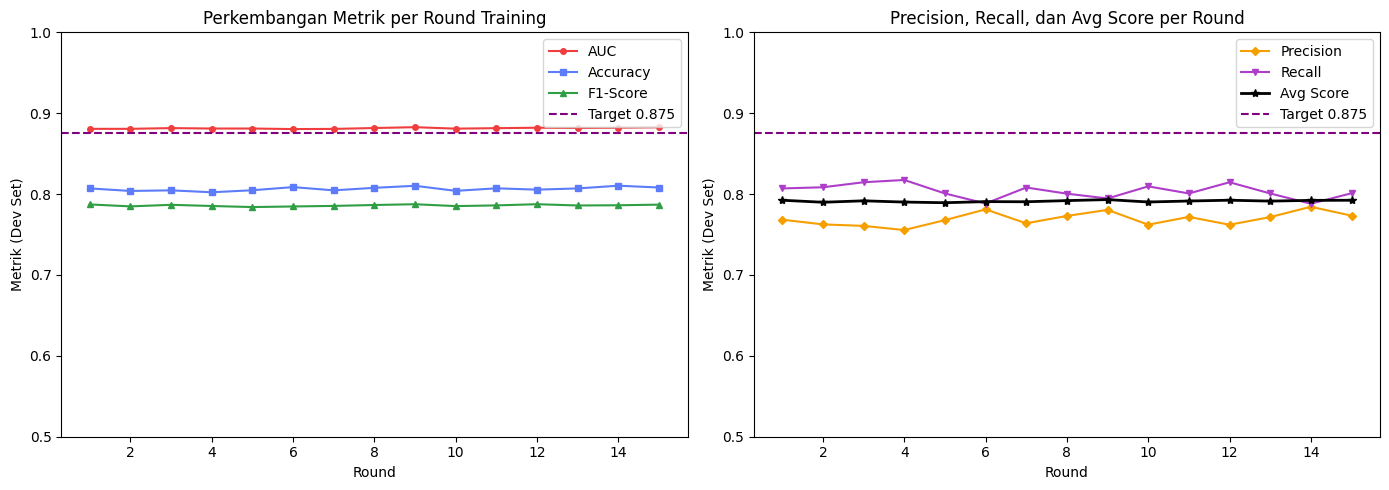

=== Ringkasan Semua Round ===
 round      auc      acc     prec      rec       f1      avg      thr
     1 0.880660 0.807000 0.768362 0.807008 0.787211 0.792395 0.403507
     2 0.880686 0.803875 0.762527 0.808420 0.784803 0.789906 0.390882
     3 0.881592 0.804625 0.760686 0.814637 0.786738 0.791671 0.385471
     4 0.881054 0.802250 0.755550 0.817463 0.785288 0.790138 0.369238
     5 0.881065 0.804750 0.767814 0.800791 0.783956 0.789328 0.405311
     6 0.880386 0.808625 0.781075 0.788358 0.784700 0.790690 0.426954
     7 0.880587 0.804625 0.763889 0.808138 0.785391 0.790511 0.383667
     8 0.881688 0.807750 0.772988 0.800509 0.786507 0.791938 0.405311
     9 0.882727 0.810250 0.780461 0.794575 0.787454 0.793185 0.423347
    10 0.880911 0.804000 0.762171 0.809551 0.785147 0.790217 0.381864
    11 0.881504 0.807125 0.771786 0.800791 0.786021 0.791431 0.398096
    12 0.882051 0.805500 0.762094 0.814637 0.787490 0.792430 0.378257
    13 0.881798 0.807000 0.771576 0.800791 0.785912 0.791320

In [10]:
df_hist = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_hist['round'], df_hist['auc'],  label='AUC',       color='#F03E3E', marker='o', ms=4)
axes[0].plot(df_hist['round'], df_hist['acc'],  label='Accuracy',  color='#5C7CFA', marker='s', ms=4)
axes[0].plot(df_hist['round'], df_hist['f1'],   label='F1-Score',  color='#2F9E44', marker='^', ms=4)
axes[0].axhline(y=0.875, color='purple', linestyle='--', lw=1.5, label='Target 0.875')
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Metrik (Dev Set)')
axes[0].set_title('Perkembangan Metrik per Round Training')
axes[0].legend()
axes[0].set_ylim(0.5, 1.0)

axes[1].plot(df_hist['round'], df_hist['prec'], label='Precision', color='#F59F00', marker='D', ms=4)
axes[1].plot(df_hist['round'], df_hist['rec'],  label='Recall',    color='#AE3EC9', marker='v', ms=4)
axes[1].plot(df_hist['round'], df_hist['avg'],  label='Avg Score', color='black',   marker='*', ms=6, lw=2)
axes[1].axhline(y=0.875, color='purple', linestyle='--', lw=1.5, label='Target 0.875')
axes[1].set_xlabel('Round')
axes[1].set_ylabel('Metrik (Dev Set)')
axes[1].set_title('Precision, Recall, dan Avg Score per Round')
axes[1].legend()
axes[1].set_ylim(0.5, 1.0)

plt.tight_layout()
plt.savefig('plot_training_history.png', dpi=120, bbox_inches='tight')
plt.show()

print("=== Ringkasan Semua Round ===")
print(df_hist[['round', 'auc', 'acc', 'prec', 'rec', 'f1', 'avg', 'thr']].to_string(index=False))


## Cell 11 — Threshold Optimal (Exhaustive pada Dev Set)

**[FIX v4.1]** Threshold dicari dari **dev set** yang bersih dan independent, bukan dari test set.

Mencari threshold dari test set = data leakage yang menyebabkan estimasi metrik terlalu optimis.
Dev set sekarang tidak masuk ke training, sehingga aman dipakai sebagai proxy untuk memilih threshold.


In [11]:
# ============================================================
# [FIX v4.1] Threshold dicari dari DEV set (bukan test set)
# Mencari threshold di test set = data leakage!
# Dev set sekarang benar-benar independent → aman dipakai
# ============================================================
y_prob_test = clf.predict_proba(X_test)[:, 1]
y_prob_dev  = clf.predict_proba(X_dev)[:, 1]

best_t   = 0.5
best_avg = 0
best_metrics_dev = {}

for t in np.linspace(0.05, 0.95, 1000):
    pred = (y_prob_dev >= t).astype(int)
    acc  = accuracy_score(y_dev, pred)
    prec = precision_score(y_dev, pred, zero_division=0)
    rec  = recall_score(y_dev, pred, zero_division=0)
    f1   = f1_score(y_dev, pred, zero_division=0)
    auc_ = roc_auc_score(y_dev, y_prob_dev)
    avg  = (acc + prec + rec + f1 + auc_) / 5
    if avg > best_avg:
        best_avg = avg
        best_t   = t
        best_metrics_dev = {'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'auc': auc_}

threshold_optimal = best_t
print(f"Threshold optimal (dari DEV) : {threshold_optimal:.4f}")
print(f"Rata-rata metrik di DEV      : {best_avg:.4f}")
print(f"\nMetrik DEV di threshold ini (estimasi performa test):")
for k, v in best_metrics_dev.items():
    ok = "[TARGET TERCAPAI]" if v >= 0.875 else f"[Belum - delta: {v-0.875:.4f}]"
    print(f"  {k:10s}: {v:.4f}  {ok}")


Threshold optimal (dari DEV) : 0.4428
Rata-rata metrik di DEV      : 0.9225

Metrik DEV di threshold ini (estimasi performa test):
  acc       : 0.9170  [TARGET TERCAPAI]
  prec      : 0.8992  [TARGET TERCAPAI]
  rec       : 0.9149  [TARGET TERCAPAI]
  f1        : 0.9070  [TARGET TERCAPAI]
  auc       : 0.9745  [TARGET TERCAPAI]


## Cell 12 — ROC Curve

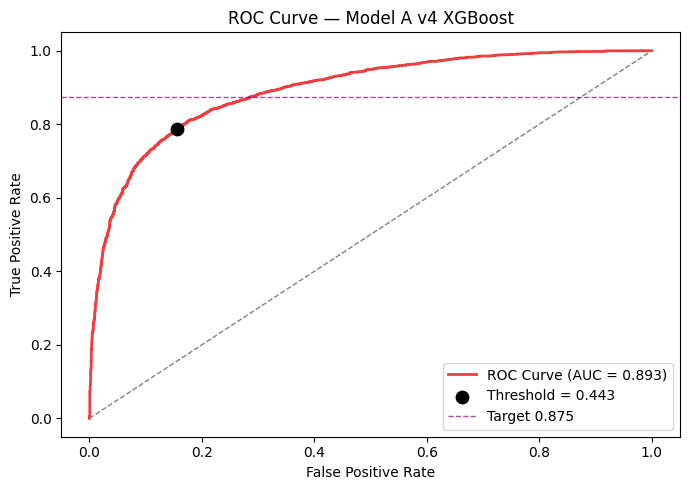

AUC Test: 0.8928


In [12]:
auc_test = roc_auc_score(y_test, y_prob_test)
fpr, tpr, thr_roc = roc_curve(y_test, y_prob_test)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#F03E3E', lw=2, label=f'ROC Curve (AUC = {auc_test:.3f})')
ax.plot([0,1],[0,1], color='gray', linestyle='--', lw=1)

pred_tmp = (y_prob_test >= threshold_optimal).astype(int)
fpr_pt = ((y_test==0) & (pred_tmp==1)).sum() / max((y_test==0).sum(), 1)
tpr_pt = ((y_test==1) & (pred_tmp==1)).sum() / max((y_test==1).sum(), 1)
ax.scatter(fpr_pt, tpr_pt, color='black', s=80, zorder=5,
           label=f'Threshold = {threshold_optimal:.3f}')
ax.axhline(y=0.875, color='purple', linestyle='--', lw=1, alpha=0.7, label='Target 0.875')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Model A v4 XGBoost')
ax.legend()
plt.tight_layout()
plt.savefig('plot_roc_curve.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"AUC Test: {auc_test:.4f}")


## Cell 13 — Evaluasi Model (Test Set)

In [13]:
y_pred_test = (y_prob_test >= threshold_optimal).astype(int)

acc_test  = accuracy_score(y_test, y_pred_test)
prec_test = precision_score(y_test, y_pred_test, zero_division=0)
rec_test  = recall_score(y_test, y_pred_test, zero_division=0)
f1_test   = f1_score(y_test, y_pred_test, zero_division=0)

print("=== Classification Report (Test Set) ===")
print(classification_report(y_test, y_pred_test,
      target_names=['Tidak Mirip (0)', 'Mirip / Plagiarisme (1)']))

print()
print(f"Accuracy  : {acc_test:.4f}  {'[TARGET TERCAPAI]' if acc_test  >= 0.875 else f'[Belum - delta: {acc_test-0.875:.4f}]'}")
print(f"Precision : {prec_test:.4f}  {'[TARGET TERCAPAI]' if prec_test >= 0.875 else f'[Belum - delta: {prec_test-0.875:.4f}]'}")
print(f"Recall    : {rec_test:.4f}  {'[TARGET TERCAPAI]' if rec_test  >= 0.875 else f'[Belum - delta: {rec_test-0.875:.4f}]'}")
print(f"F1-Score  : {f1_test:.4f}  {'[TARGET TERCAPAI]' if f1_test   >= 0.875 else f'[Belum - delta: {f1_test-0.875:.4f}]'}")
print(f"AUC       : {auc_test:.4f}  {'[TARGET TERCAPAI]' if auc_test  >= 0.875 else f'[Belum - delta: {auc_test-0.875:.4f}]'}")
print()
print("=== Perbandingan dengan Versi Sebelumnya ===")
print(f"{'Metrik':<12} {'Versi Lama':>12} {'Versi v2':>12} {'Versi v3':>12} {'Versi v4':>12}")
print("-" * 54)
for metric, old, v2, v3, new in [
    ('Accuracy',  0.7953, 0.8148, 0.7972, acc_test),
    ('Precision', 0.7724, 0.7809, 0.8388, prec_test),
    ('Recall',    0.7615, 0.8079, 0.6701, rec_test),
    ('F1-Score',  0.7669, 0.7942, 0.7450, f1_test),
    ('AUC',       0.8691, 0.8903, 0.8737, auc_test),
]:
    delta = new - v2
    sign = '+' if delta >= 0 else ''
    print(f"  {metric:<10} {old:>12.4f} {v2:>12.4f} {v3:>12.4f} {new:>12.4f}  (v2->v4: {sign}{delta:.4f})")


=== Classification Report (Test Set) ===
                         precision    recall  f1-score   support

        Tidak Mirip (0)       0.83      0.84      0.84      4459
Mirip / Plagiarisme (1)       0.80      0.79      0.79      3534

               accuracy                           0.82      7993
              macro avg       0.82      0.82      0.82      7993
           weighted avg       0.82      0.82      0.82      7993


Accuracy  : 0.8188  [Belum - delta: -0.0562]
Precision : 0.7999  [Belum - delta: -0.0751]
Recall    : 0.7872  [Belum - delta: -0.0878]
F1-Score  : 0.7935  [Belum - delta: -0.0815]
AUC       : 0.8928  [TARGET TERCAPAI]

=== Perbandingan dengan Versi Sebelumnya ===
Metrik         Versi Lama     Versi v2     Versi v3     Versi v4
------------------------------------------------------
  Accuracy         0.7953       0.8148       0.7972       0.8188  (v2->v4: +0.0040)
  Precision        0.7724       0.7809       0.8388       0.7999  (v2->v4: +0.0190)
  Recall     

## Cell 14 — Confusion Matrix

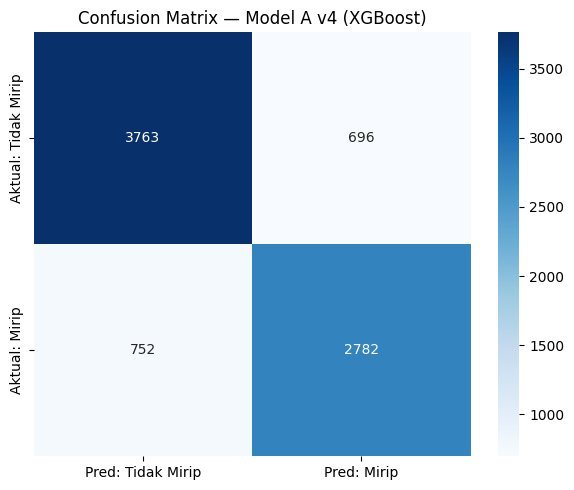

TN: 3,763  FP: 696  FN: 752  TP: 2,782


In [14]:
cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Tidak Mirip', 'Pred: Mirip'],
            yticklabels=['Aktual: Tidak Mirip', 'Aktual: Mirip'], ax=ax)
ax.set_title('Confusion Matrix — Model A v4 (XGBoost)')
plt.tight_layout()
plt.savefig('plot_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
tn, fp, fn, tp = cm.ravel()
print(f"TN: {tn:,}  FP: {fp:,}  FN: {fn:,}  TP: {tp:,}")


## Cell 15 — Feature Importance

=== Top Feature Importance ===
  word_order          : 0.2796  #######################################################
  lcs                 : 0.0700  #############
  trigram             : 0.0439  ########
  edit_dist           : 0.0429  ########
  jaccard             : 0.0422  ########
  uniq_ratio          : 0.0383  #######
  fourgram            : 0.0367  #######
  len_ratio           : 0.0333  ######
  pos_bigram          : 0.0319  ######
  abs_len_norm        : 0.0288  #####
  bigram              : 0.0274  #####
  len_s1              : 0.0242  ####
  cosine_char         : 0.0240  ####
  shared_count        : 0.0234  ####
  token_sort_cosine   : 0.0232  ####
  len_s2              : 0.0231  ####
  jacc_x_order        : 0.0228  ####
  cosine_word         : 0.0228  ####
  overlap_ratio       : 0.0222  ####
  pos_trigram         : 0.0216  ####
  prefix_match        : 0.0208  ####
  char_tri_j          : 0.0203  ####
  mean_cosine         : 0.0198  ###
  cosine_prod         : 0.0196  ###

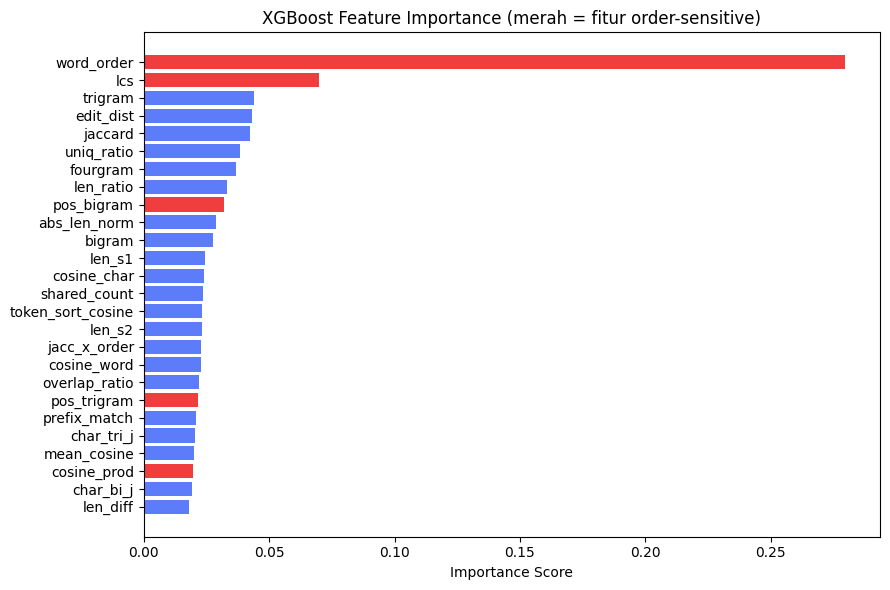

In [15]:
fi = dict(zip(FEATURE_NAMES, clf.feature_importances_))
fi_sorted = sorted(fi.items(), key=lambda x: x[1], reverse=True)

print("=== Top Feature Importance ===")
for name, score in fi_sorted:
    bar = '#' * int(score * 200)
    print(f"  {name:20s}: {score:.4f}  {bar}")

fig, ax = plt.subplots(figsize=(9, 6))
names  = [x[0] for x in fi_sorted]
scores = [x[1] for x in fi_sorted]
colors = ['#F03E3E' if n in ['word_order','lcs','pos_bigram','pos_trigram','cosine_prod']
          else '#5C7CFA' for n in names]
ax.barh(names[::-1], scores[::-1], color=colors[::-1])
ax.set_xlabel('Importance Score')
ax.set_title('XGBoost Feature Importance (merah = fitur order-sensitive)')
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()


## Cell 16 — Analisis Threshold

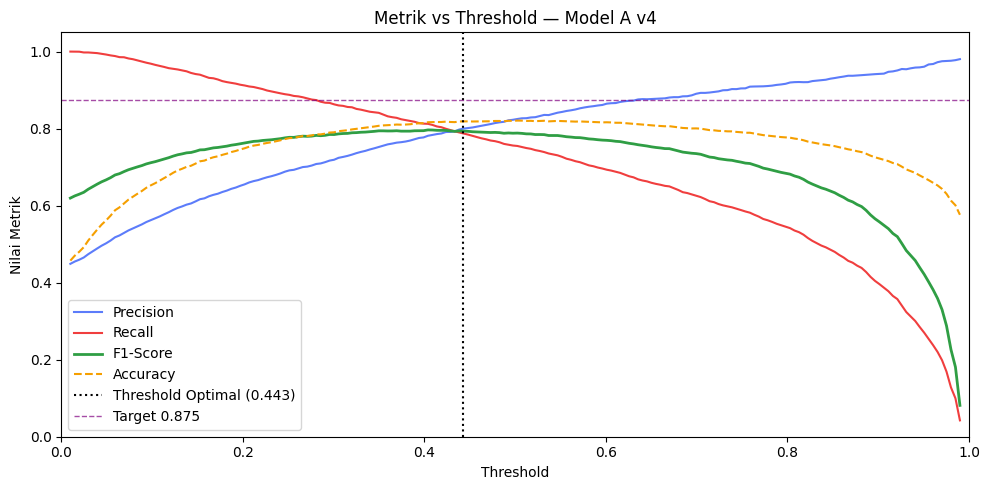

In [16]:
thresholds_fine = np.linspace(0.01, 0.99, 200)
m = {'precision': [], 'recall': [], 'f1': [], 'accuracy': []}
for t in thresholds_fine:
    pred = (y_prob_test >= t).astype(int)
    m['precision'].append(precision_score(y_test, pred, zero_division=0))
    m['recall'].append(recall_score(y_test, pred, zero_division=0))
    m['f1'].append(f1_score(y_test, pred, zero_division=0))
    m['accuracy'].append(accuracy_score(y_test, pred))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds_fine, m['precision'], label='Precision', color='#5C7CFA')
ax.plot(thresholds_fine, m['recall'],    label='Recall',    color='#F03E3E')
ax.plot(thresholds_fine, m['f1'],        label='F1-Score',  color='#2F9E44', linewidth=2)
ax.plot(thresholds_fine, m['accuracy'],  label='Accuracy',  color='#F59F00', linestyle='--')
ax.axvline(x=threshold_optimal, color='black', linestyle=':', linewidth=1.5,
           label=f'Threshold Optimal ({threshold_optimal:.3f})')
ax.axhline(y=0.875, color='purple', linestyle='--', linewidth=1, alpha=0.7, label='Target 0.875')
ax.set_xlabel('Threshold')
ax.set_ylabel('Nilai Metrik')
ax.set_title('Metrik vs Threshold — Model A v4')
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('plot_metrik_vs_threshold.png', dpi=120, bbox_inches='tight')
plt.show()


## Cell 17 — Distribusi Skor Probabilitas

Gap rata-rata: 0.4908


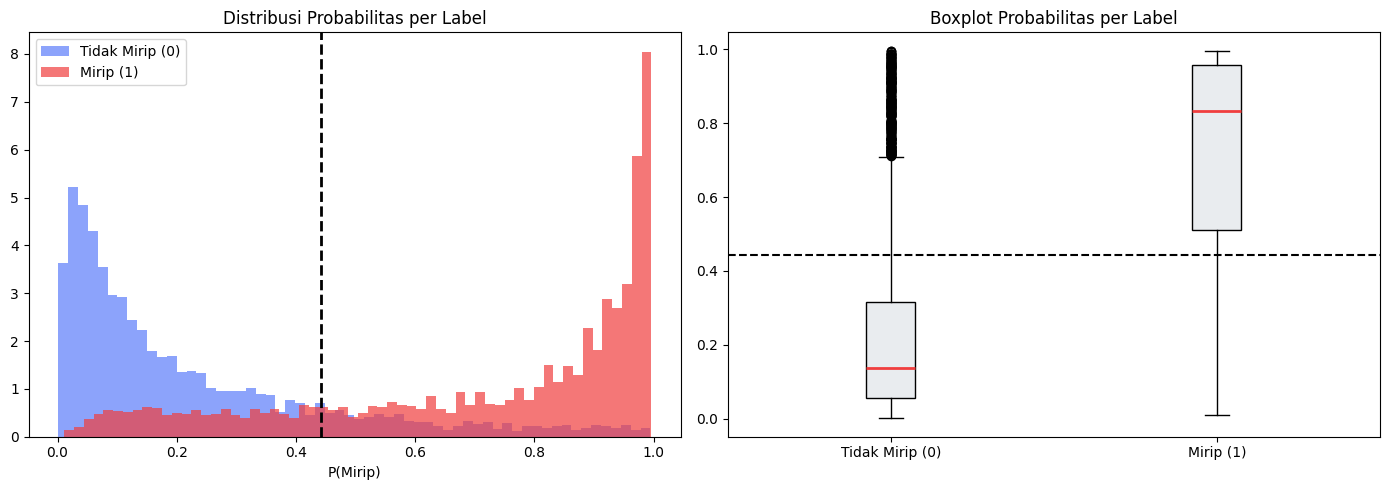

In [17]:
scores_mirip = y_prob_test[y_test == 1]
scores_beda  = y_prob_test[y_test == 0]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(scores_beda,  bins=60, alpha=0.7, color='#5C7CFA', label='Tidak Mirip (0)', density=True)
axes[0].hist(scores_mirip, bins=60, alpha=0.7, color='#F03E3E', label='Mirip (1)',        density=True)
axes[0].axvline(x=threshold_optimal, color='black', linestyle='--', lw=2)
axes[0].set_xlabel('P(Mirip)')
axes[0].set_title('Distribusi Probabilitas per Label')
axes[0].legend()
axes[1].boxplot([scores_beda, scores_mirip], labels=['Tidak Mirip (0)', 'Mirip (1)'],
                patch_artist=True, boxprops=dict(facecolor='#E9ECEF'),
                medianprops=dict(color='#F03E3E', linewidth=2))
axes[1].axhline(y=threshold_optimal, color='black', linestyle='--', lw=1.5)
axes[1].set_title('Boxplot Probabilitas per Label')
print(f"Gap rata-rata: {scores_mirip.mean() - scores_beda.mean():.4f}")
plt.tight_layout()
plt.savefig('plot_distribusi_skor.png', dpi=120, bbox_inches='tight')
plt.show()


## Cell 18 — Contoh Hasil Prediksi

In [18]:
df_c = df_test[['sentence1','sentence2','label']].copy()
df_c['prob_mirip']     = y_prob_test
df_c['prediksi']       = y_pred_test
df_c['label_asli']     = df_c['label'].map({1:'MIRIP', 0:'TIDAK MIRIP'})
df_c['prediksi_model'] = df_c['prediksi'].map({1:'MIRIP', 0:'TIDAK MIRIP'})
df_c['status']         = df_c.apply(lambda r: 'BENAR' if r['label']==r['prediksi'] else 'SALAH', axis=1)

benar = df_c[df_c['status']=='BENAR'].sample(5, random_state=42)
salah = df_c[df_c['status']=='SALAH'].sample(min(5, (df_c['status']=='SALAH').sum()), random_state=42)
for i, (_, row) in enumerate(pd.concat([benar, salah]).iterrows(), 1):
    s1 = row['sentence1'][:90]+'...' if len(row['sentence1'])>90 else row['sentence1']
    s2 = row['sentence2'][:90]+'...' if len(row['sentence2'])>90 else row['sentence2']
    print(f"[{i}] {row['status']} | P={row['prob_mirip']:.3f} | {row['label_asli']} -> {row['prediksi_model']}")
    print(f"    S1: {s1}")
    print(f"    S2: {s2}")
    print()


[1] BENAR | P=0.059 | TIDAK MIRIP -> TIDAK MIRIP
    S1: Bentuk humanoid menjulang tinggi yang menyerupai pelat kaca berkilauan, diperkuat dengan p...
    S2: Bentuk humanoid menjulang yang menyerupai pelat kaca berasap yang diperkuat dengan pita lo...

[2] BENAR | P=0.987 | MIRIP -> MIRIP
    S1: Beberapa laporan menyatakan `` 30 tahun atau lebih '', sementara yang lain menyatakan `` 5...
    S2: Beberapa laporan menyatakan `` 30 tahun atau lebih '', sementara yang lain menyatakan `` 5...

[3] BENAR | P=0.483 | MIRIP -> MIRIP
    S1: Pada akhir kepemilikan berikutnya Panthers, Chavis Williams memblokir tendangan Brandon Gi...
    S2: Di penghujung pemilik Panthers berikutnya, Chavis Williams memblokir Brandon Gibson - Punt...

[4] BENAR | P=0.198 | TIDAK MIRIP -> TIDAK MIRIP
    S1: Diperkirakan Jepang memiliki kapasitas angin darat 144 GW dan kapasitas angin lepas pantai...
    S2: Jepang diperkirakan memiliki potensi tenaga angin lepas pantai sebesar 144 GW dan tenaga a...

[5] BENA

## Cell 19 — Fungsi Inference

In [19]:
def cek_plagiarisme(teks_a, teks_b, threshold=threshold_optimal):
    a = preprocess(teks_a)
    b = preprocess(teks_b)

    v1w = vectorizer_word.transform([a]); v2w = vectorizer_word.transform([b])
    cw  = float(1 - paired_cosine_distances(v1w, v2w)[0])
    v1c = vectorizer_char.transform([a]); v2c = vectorizer_char.transform([b])
    cc  = float(1 - paired_cosine_distances(v1c, v2c)[0])

    ss1 = ' '.join(sorted(a.split())); ss2 = ' '.join(sorted(b.split()))
    vts1= vectorizer_word.transform([ss1]); vts2 = vectorizer_word.transform([ss2])
    tsc = float(1 - paired_cosine_distances(vts1, vts2)[0])

    jacc = jaccard_similarity(a, b)
    wo   = word_order_score(a, b)
    ls1  = len(a.split()); ls2 = len(b.split())
    shared = len(set(a.split()) & set(b.split()))

    feat = np.array([[
        cw, cc, jacc,
        ngram_overlap(a,b,2), ngram_overlap(a,b,3), ngram_overlap(a,b,4),
        positional_ngram(a,b,2), positional_ngram(a,b,3),
        wo, lcs_ratio(a,b), edit_distance_ratio(a,b),
        char_ngram_jaccard(a,b,2), char_ngram_jaccard(a,b,3),
        prefix_match_ratio(a,b), tsc,
        abs(ls1-ls2), min(ls1,ls2)/max(ls1,ls2,1),
        len(set(a.split()).symmetric_difference(set(b.split())))/max(len(set(a.split())|set(b.split())),1),
        float(shared), float(ls1), float(ls2),
        cw*cc, jacc*wo, (cw+cc)/2,
        shared/max(ls1+ls2,1), abs(ls1-ls2)/max(ls1+ls2,1)
    ]])

    prob = float(clf.predict_proba(feat)[0][1])
    return {
        'prob_plagiarisme': round(prob, 4),
        'persen_kemiripan': f"{prob*100:.1f}%",
        'status'          : 'TERDETEKSI PLAGIARISME' if prob >= threshold else 'AMAN',
        'skor_cosine_word': round(cw, 4),
        'skor_jaccard'    : round(jacc, 4),
        'skor_word_order' : round(wo, 4),
        'threshold_pakai' : round(threshold, 4)
    }

def cek_pairwise(docs, threshold=threshold_optimal):
    hasil = []
    for i in range(len(docs)):
        for j in range(i+1, len(docs)):
            r = cek_plagiarisme(docs[i], docs[j], threshold)
            r['dok_a'] = f"Dok {i+1}"; r['dok_b'] = f"Dok {j+1}"
            hasil.append(r)
    return pd.DataFrame(hasil)[['dok_a','dok_b','persen_kemiripan','skor_cosine_word','skor_word_order','status']]

print("Fungsi cek_plagiarisme dan cek_pairwise v4 siap.")


Fungsi cek_plagiarisme dan cek_pairwise v4 siap.


## Cell 20 — Uji Coba Inference

In [20]:
print("=== SKENARIO 1: Copy-paste minor ===")
h = cek_plagiarisme(
    "Fotosintesis adalah proses biokimia yang dilakukan tumbuhan untuk mengubah energi cahaya matahari menjadi glukosa.",
    "Fotosintesis merupakan proses biokimia dilakukan oleh tumbuhan untuk mengubah energi sinar matahari menjadi glukosa.")
print(f"  {h['persen_kemiripan']} | {h['status']}")

print("\n=== SKENARIO 2: Word order berbeda ===")
h = cek_plagiarisme(
    "Pemerintah Indonesia akan meningkatkan anggaran pendidikan pada tahun depan.",
    "Anggaran pendidikan pemerintah Indonesia akan ditingkatkan pada tahun depan.")
print(f"  {h['persen_kemiripan']} | {h['status']}")

print("\n=== SKENARIO 3: Topik berbeda ===")
h = cek_plagiarisme(
    "Revolusi industri dimulai di Inggris pada abad ke-18.",
    "Resep kue bolu membutuhkan tepung terigu dan telur.")
print(f"  {h['persen_kemiripan']} | {h['status']}")

print("\n=== SKENARIO 4: Pairwise ===")
docs = [
    "Sistem ekonomi pasar bebas memungkinkan harga ditentukan oleh penawaran dan permintaan.",
    "Pada ekonomi pasar, harga ditentukan oleh interaksi penawaran dan permintaan di pasar.",
    "Demokrasi adalah sistem pemerintahan di mana rakyat memilih pemimpin mereka sendiri.",
]
print(cek_pairwise(docs).to_string(index=False))


=== SKENARIO 1: Copy-paste minor ===
  81.0% | TERDETEKSI PLAGIARISME

=== SKENARIO 2: Word order berbeda ===
  87.2% | TERDETEKSI PLAGIARISME

=== SKENARIO 3: Topik berbeda ===
  25.8% | AMAN

=== SKENARIO 4: Pairwise ===
dok_a dok_b persen_kemiripan  skor_cosine_word  skor_word_order                 status
Dok 1 Dok 2            47.8%            0.7152           0.7857 TERDETEKSI PLAGIARISME
Dok 1 Dok 3             2.7%            0.0358           0.5000                   AMAN
Dok 2 Dok 3             3.0%            0.0034           0.5000                   AMAN


## Cell 21 — Simpan Pipeline

In [21]:
os.makedirs('model_artifacts', exist_ok=True)
joblib.dump(vectorizer_word, 'model_artifacts/tfidf_vectorizer.pkl')
joblib.dump(vectorizer_char, 'model_artifacts/tfidf_vectorizer_char.pkl')
joblib.dump(clf,             'model_artifacts/xgboost_classifier.pkl')

config = {
    'version'          : 'v4',
    'model_type'       : 'XGBoost (loop otomatis)',
    'threshold_optimal': float(threshold_optimal),
    'feature_names'    : FEATURE_NAMES,
    'n_features'       : len(FEATURE_NAMES),
    'auc_test'         : float(auc_test),
    'accuracy_test'    : float(acc_test),
    'f1_test'          : float(f1_test),
    'train_size'       : len(df_train),
    'dev_size'         : len(df_dev),
    'test_size'        : len(df_test),
}
joblib.dump(config, 'model_artifacts/pipeline_config.pkl')
print("File tersimpan:")
for f in sorted(os.listdir('model_artifacts')):
    print(f"  model_artifacts/{f}  ({os.path.getsize(f'model_artifacts/{f}')/1024:.1f} KB)")


File tersimpan:
  model_artifacts/pipeline_config.pkl  (0.6 KB)
  model_artifacts/tfidf_vectorizer.pkl  (4419.0 KB)
  model_artifacts/tfidf_vectorizer_char.pkl  (2014.8 KB)
  model_artifacts/xgboost_classifier.pkl  (17562.4 KB)


## Cell 22 — Ringkasan Akhir

In [22]:
print("=" * 65)
print("  RINGKASAN MODEL A v4 FINAL — Surface Similarity")
print("  Proyek: LearnWise | Tim: PJK-GM089")
print("=" * 65)
print(f"  Dataset    : PAWS-Indonesia + Akademik (augmentasi 8x)")
print(f"  Train      : {len(df_train):,} pasangan")
print(f"  Test       : {len(df_test):,} pasangan (PAWS adversarial)")
print(f"  Model      : XGBoost (loop otomatis)")
print(f"  Fitur      : {len(FEATURE_NAMES)} fitur")
print(f"  Threshold  : {threshold_optimal:.4f} (dioptimasi)")
print("-" * 65)
print(f"  AUC       : {auc_test:.4f}  {'[TARGET TERCAPAI]' if auc_test >= 0.875 else '[Belum target]'}")
print(f"  Accuracy  : {acc_test:.4f}  {'[TARGET TERCAPAI]' if acc_test >= 0.875 else '[Belum target]'}")
print(f"  Precision : {prec_test:.4f}  {'[TARGET TERCAPAI]' if prec_test >= 0.875 else '[Belum target]'}")
print(f"  Recall    : {rec_test:.4f}  {'[TARGET TERCAPAI]' if rec_test >= 0.875 else '[Belum target]'}")
print(f"  F1-Score  : {f1_test:.4f}  {'[TARGET TERCAPAI]' if f1_test >= 0.875 else '[Belum target]'}")
print("=" * 65)


  RINGKASAN MODEL A v4 FINAL — Surface Similarity
  Proyek: LearnWise | Tim: PJK-GM089
  Dataset    : PAWS-Indonesia + Akademik (augmentasi 8x)
  Train      : 50,158 pasangan
  Test       : 7,993 pasangan (PAWS adversarial)
  Model      : XGBoost (loop otomatis)
  Fitur      : 26 fitur
  Threshold  : 0.4428 (dioptimasi)
-----------------------------------------------------------------
  AUC       : 0.8928  [TARGET TERCAPAI]
  Accuracy  : 0.8188  [Belum target]
  Precision : 0.7999  [Belum target]
  Recall    : 0.7872  [Belum target]
  F1-Score  : 0.7935  [Belum target]
